# **Pie Charts**


- This exercise, will focus on visualizing data.

- The provided dataset will be loaded into pandas for analysis.

- Various pie charts will be created to:
   - Analyze developer preferences.
  
   - Identify technology usage trends.
    
- The lab aims to provide insights into key variables using visual representations.


## Objectives


This exercise will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition of data.

-   Visualize comparison of data.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [13]:
import nbformat

filename = "Lab 21 Pie Charts.ipynb"

# Read the notebook as plain JSON first
with open(filename, "r", encoding="utf-8") as f:
    data = f.read()

import json
notebook = json.loads(data)

# Fix every cell whose source is a string
for cell in notebook["cells"]:
    if isinstance(cell.get("source"), str):
        cell["source"] = cell["source"].splitlines(keepends=True)

# Make sure code cells have required fields
for cell in notebook["cells"]:
    if cell["cell_type"] == "code":
        if "outputs" not in cell:
            cell["outputs"] = []
        if "execution_count" not in cell:
            cell["execution_count"] = None

# Write the corrected notebook
with open("Lab 21 Pie Charts_fixed.ipynb", "w", encoding="utf-8") as f:
    json.dump(notebook, f, indent=1)

print("Created: Lab 21 Pie Charts_fixed.ipynb")


Created: Lab 21 Pie Charts_fixed.ipynb

In [5]:
!pip install pandas
!pip install matplotlib

**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



In [6]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()



--2026-09-28 04:40:01--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  35.8MB/s    in 4.3s    

2026-09-28 04:40:05 (35.1 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Composition with Pie Charts


##### 1.1 Create a Pie Chart of the Top 5 Databases Respondents Want to Work With


In the survey data, the `DatabaseWantToWorkWith` column lists the databases that respondents wish to work with. Let’s visualize the top 5 most-desired databases in a pie chart.



DatabaseWantToWorkWith
PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: count, dtype: int64Database_want
PostgreSQL    24005.0
SQLite        13489.0
MySQL         12269.0
MongoDB       10982.0
Redis         10847.0
Name: count, dtype: float64

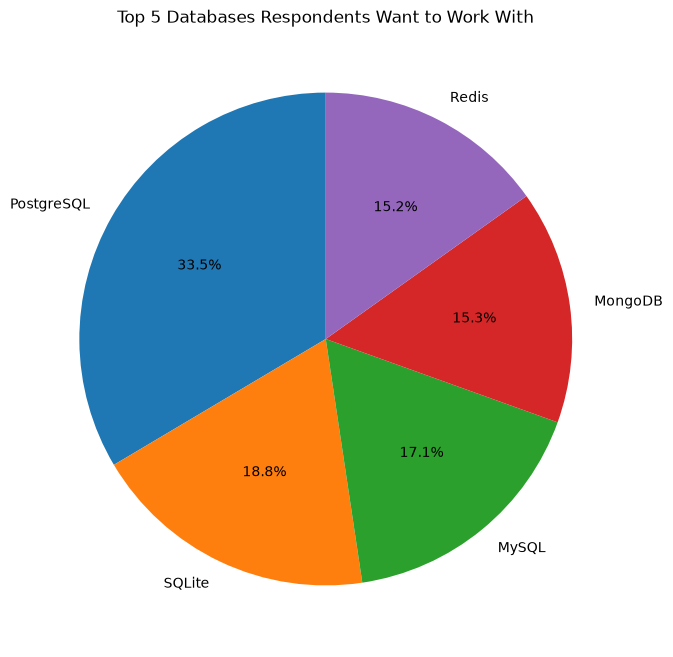

In [7]:
Database_want = df["DatabaseWantToWorkWith"].str.split(";").explode().str.strip().value_counts().head()
print(Database_want)
df["Database_want"] = df["DatabaseWantToWorkWith"].str.split(";")
df= df.explode("Database_want")
df["Database_want"] = df["Database_want"].str.strip()
new_database_want = df[df["Database_want"].isin(Database_want.index)]
pie_database_want = new_database_want["Database_want"].value_counts().dropna()
pie_database_want = pie_database_want.astype(float)

print (pie_database_want)

plt.figure (figsize = (12,8))
plt.pie(x = pie_database_want.values,labels = pie_database_want.index, startangle= 90, autopct = "% 1.1f%%")
plt.title("Top 5 Databases Respondents Want to Work With")
plt.show()

The `DevType` column lists the developer types for respondents. We’ll examine the distribution by showing the top 5 developer roles in a pie chart.



##### 1.3 Create a pie chart for the operating systems used by respondents for professional use


The `OpSysProfessional` use column shows the operating systems developers use professionally. Let’s visualize the distribution of the top operating systems in a pie chart.



OpSysProfessional use
Windows                                             21200
MacOS                                               18363
Ubuntu                                               8067
Windows;Windows Subsystem for Linux (WSL)            7110
Ubuntu;Windows;Windows Subsystem for Linux (WSL)     4676
Name: count, dtype: int64

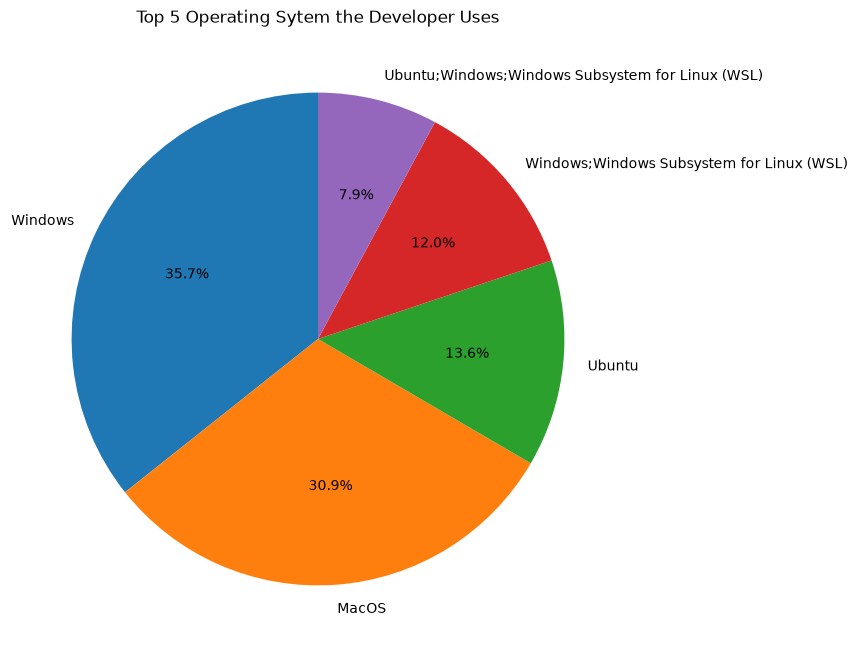

In [8]:

op_system = df["OpSysProfessional use"].value_counts().head(5)
print(op_system)
plt.figure (figsize = (12,8))
plt.pie(x = op_system.values,labels = op_system.index, startangle= 90, autopct = "% 1.1f%%")
plt.title("Top 5 Operating Sytem the Developer Uses")
plt.show()

### Task 2: Additional Visualizations and Comparisons


##### 2.1 Pie Chart for Top 5 Programming Languages Respondents Have Worked With


The `LanguageHaveWorkedWith` column contains the programming languages that respondents have experience with. We’ll plot a pie chart to display the composition of the top 5 languages.



##### 2.2 Pie Chart for Top Collaboration Tools used in Professional Use


Using the `NEWCollabToolsHaveWorkedWith` column, we’ll identify and visualize the top collaboration tools respondents use in their professional work.



0                                        NaN
1        PyCharm;Visual Studio Code;WebStorm
2                              Visual Studio
3                                        NaN
3                                        NaN
                        ...                 
65435                 Vim;Visual Studio Code
65435                 Vim;Visual Studio Code
65436                     Visual Studio Code
65436                     Visual Studio Code
65436                     Visual Studio Code
Name: NEWCollabToolsHaveWorkedWith, Length: 150318, dtype: str

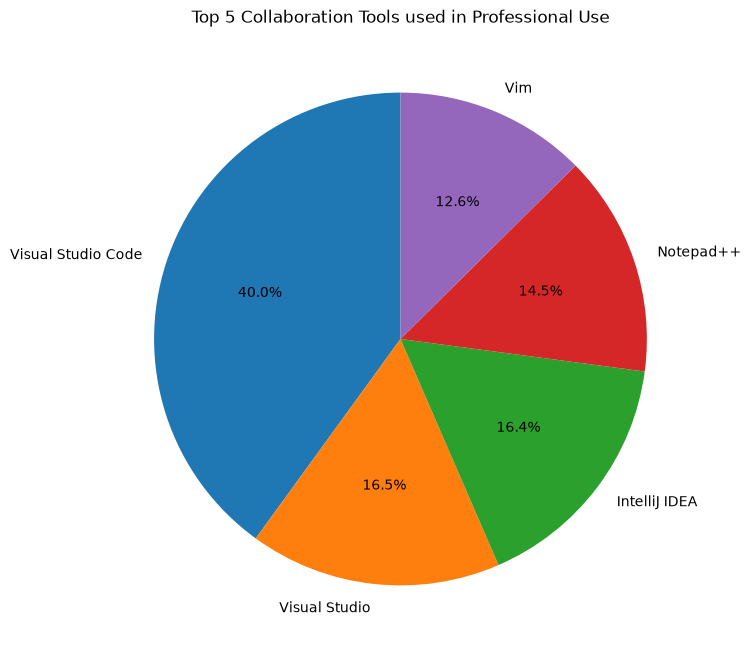

In [9]:
print(df["NEWCollabToolsHaveWorkedWith"])
Collaboration = df["NEWCollabToolsHaveWorkedWith"].str.split(";").explode().str.strip().value_counts().head(5)
plt.figure (figsize = (12,8))
plt.pie(x = Collaboration.values,labels = Collaboration.index, startangle= 90, autopct = "%1.1f%%")
plt.title("Top 5 Collaboration Tools used in Professional Use")
plt.show()

### Task 3: Analyzing and Interpreting Composition


In this task, you will create additional pie charts to analyze specific aspects of the survey data. Use `pandas` and `matplotlib` to complete each task and interpret the findings.



##### 3.1 Pie Chart of `Respondents` Most Admired Programming Languages


The `LanguageAdmired` column lists the programming languages respondents admire most. Create a pie chart to visualize the top 5 admired languages.



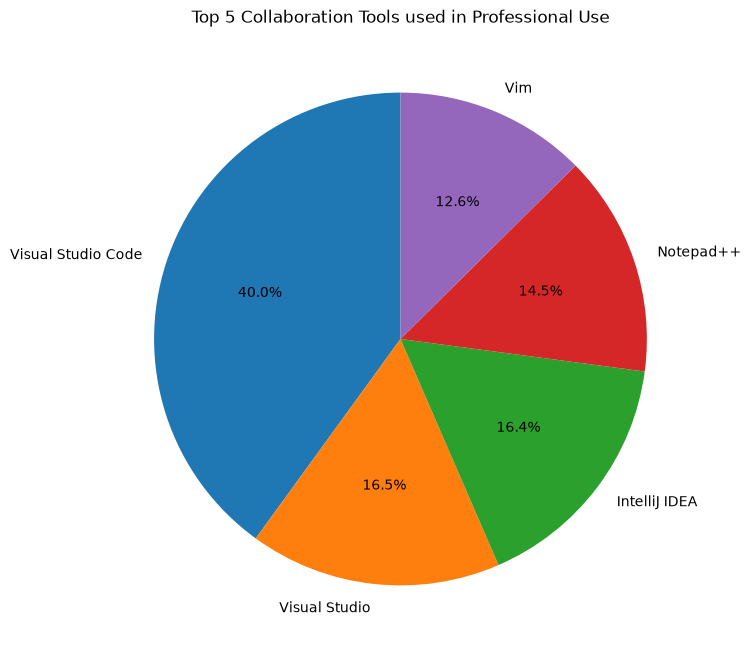

In [7]:
Collaboration = df["NEWCollabToolsHaveWorkedWith"].str.split(";").explode().str.strip().value_counts().head(5)
plt.figure (figsize = (12,8))
plt.pie(x = Collaboration.values,labels = Collaboration.index, startangle= 90, autopct = "%1.1f%%")
plt.title("Top 5 Collaboration Tools used in Professional Use")
plt.show()

##### 3.2 Pie Chart of Tools Used for AI Development


Using the `AIToolCurrently` Using column, create a pie chart to visualize the top 5 tools developers are currently using for AI development.



3        Learning about a codebase;Project planning;Wri...
3        Learning about a codebase;Project planning;Wri...
3        Learning about a codebase;Project planning;Wri...
5                  Writing code;Debugging and getting help
7        Writing code;Debugging and getting help;Search...
                               ...                        
65427    Writing code;Debugging and getting help;Search...
65427    Writing code;Debugging and getting help;Search...
65429              Writing code;Debugging and getting help
65430    Writing code;Documenting code;Debugging and ge...
65432    Learning about a codebase;Project planning;Wri...
Name: AIToolCurrently Using, Length: 90329, dtype: str

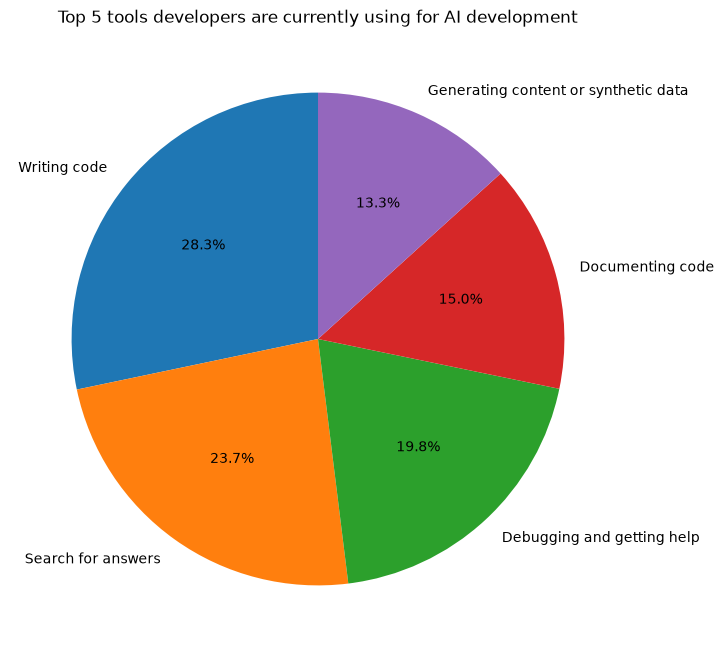

In [10]:
df["AIToolCurrently Using"] = df["AIToolCurrently Using"].str.strip()
print(df["AIToolCurrently Using"].dropna())
AI_tool = df["AIToolCurrently Using"].str.split(";").explode().str.strip().value_counts().head(5)

plt.figure(figsize = (12,8))
plt.pie(x= AI_tool.values, labels= AI_tool.index, autopct= "%1.1f%%", startangle=90)
plt.title("Top 5 tools developers are currently using for AI development")
plt.show()


##### 3.3 Pie Chart for Preferred Web Frameworks


The `WebframeWantToWorkWith` column includes web frameworks that respondents are interested in working with. Visualize the top 5 frameworks in a pie chart.


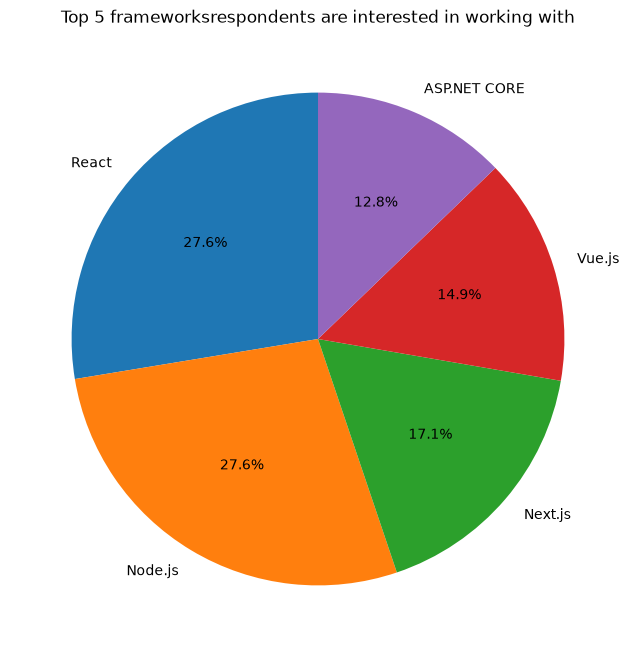

In [11]:
web_towork = df["WebframeWantToWorkWith"].str.split(";").explode().str.strip().value_counts().head(5)

plt.figure(figsize = (12,8))
plt.pie(x= web_towork.values, labels= web_towork.index, autopct= "%1.1f%%", startangle=90)
plt.title("Top 5 frameworksrespondents are interested in working with")
plt.show()

##### 3.4 Pie Chart for Most Desired Embedded Technologies


Using the `EmbeddedWantToWorkWith` column, create a pie chart to show the top 5 most desired embedded technologies that respondents wish to work with.



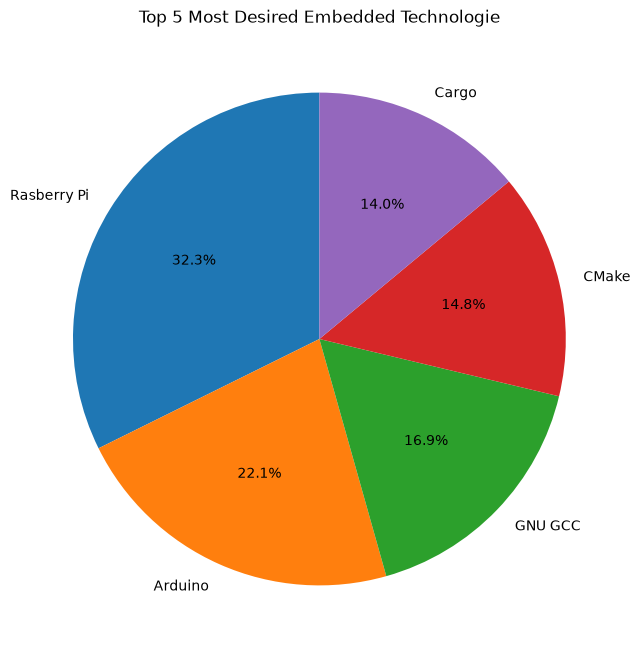

In [12]:
Embed_towork = df["EmbeddedWantToWorkWith"].str.split(";").explode().str.strip().value_counts().head(5)

plt.figure(figsize = (12,8))
plt.pie(x= Embed_towork.values, labels= Embed_towork.index, autopct= "%1.1f%%", startangle=90)
plt.title("Top 5 Most Desired Embedded Technologie")
plt.show()

### Summary



- Create pie charts to visualize developer preferences across databases, programming languages, AI tools, and cloud platforms.
- Identify trends in technology usage, role distribution, and tool adoption through pie charts.
- Analyze and compare data composition across various categories to gain insights into developer preferences.


Copyright © IBM Corporation. All rights reserved.
